<h1 style = "color: orange;">Projet Frameworks IA Big Data  : Prédiction du prix des maisons</h1>

Projet réalisé par: 
<ul>
    <li>BAH Thahir (MIBD)</li>
    <li>CISSOKO Mohamed Hossane (MIBD)</li>
    <li>HADDOU Nesrine Dalila (MSID)</li>
    <li>MBOLATIANA Fesia Clairina (MIBD)</li>
</ul>

Ce notebook présente une analyse complète du jeu de données "houses.csv" dans le but de construire un modèle capable de prédire le prix d'une maison en fonction de ses caractéristiques.

Ce jeu de données contient les prix de vente des maisons entre mai 2014 et mai 2015 pour la ville de King, qui se situe à Seattle. 

Les étapes suivies sont:
1. [Chargement et Exploration des Données](#etape-1--chargement-et-exploration-des-données)
2. [Analyse Exploratoire et Prétraitement des Données](#etape-2--analyse-exploratoire-et-prétraitement-des-données)
3. [Modélisation](#etape-3--modélisation)
1. [Conclusion](#etape-4--conclusion)

## **Etape 1 : Chargement et Exploration des Données**

In [1]:
## Gestion des warnings
import warnings
warnings.filterwarnings("ignore")

### 1.1 Installation des librairies nécessaires

In [ ]:
#!pip install pandas numpy matplotlib  seaborn scikit-learn scipy tensorflow pickle yellowbrick

### 1.2 Importation des librairies 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from scipy.cluster.hierarchy import dendrogram
import tensorflow as tf
import pickle
from yellowbrick.cluster import KElbowVisualizer

### 1.3 Chargement des données 

In [4]:
file_path = 'house.csv'
data = pd.read_csv(file_path)

### 1.4 Premier aperçu des données 

In [5]:
data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Premières observations :**
-   Le jeu de données contient 21613  entrées et 21 colonnes.
-   Toutes les colonnes semblent être numériques (int64 ou float64) avec une colonne qui contient les dates.
-   Il n'y a pas de valeurs nulles au format standard (NaN).

## **Etape 2 : Analyse Exploratoire et Prétraitement des Données**

### 2.1 Gestion du typage des données

In [8]:
# Formatage des dates
data['date'] = pd.to_datetime(data['date'])

### 2.2 Gestion des lignes dupliquées

In [9]:
data.duplicated().sum()

0

Aucune ligne ne semble avoir été dupliquée

### 2.4 Analyse et visualisation des variables explicatives

In [10]:
# Affichage du contenu de chaque variables

for cols in data.columns:
    print("---------- Colonne : ",cols, "----------------")
    print(data[cols].unique())
    print("\n")

---------- Colonne :  id ----------------
[7129300520 6414100192 5631500400 ... 1523300141  291310100 1523300157]


---------- Colonne :  date ----------------
<DatetimeArray>
['2014-10-13 00:00:00', '2014-12-09 00:00:00', '2015-02-25 00:00:00',
 '2015-02-18 00:00:00', '2014-05-12 00:00:00', '2014-06-27 00:00:00',
 '2015-01-15 00:00:00', '2015-04-15 00:00:00', '2015-03-12 00:00:00',
 '2015-04-03 00:00:00',
 ...
 '2015-03-08 00:00:00', '2014-08-30 00:00:00', '2015-05-27 00:00:00',
 '2015-03-22 00:00:00', '2015-02-15 00:00:00', '2014-10-11 00:00:00',
 '2015-02-01 00:00:00', '2014-11-30 00:00:00', '2014-08-24 00:00:00',
 '2014-07-27 00:00:00']
Length: 372, dtype: datetime64[ns]


---------- Colonne :  price ----------------
[ 221900.  538000.  180000. ...  610685. 1007500.  402101.]


---------- Colonne :  bedrooms ----------------
[ 3  2  4  5  1  6  7  0  8  9 11 10 33]


---------- Colonne :  bathrooms ----------------
[1.   2.25 3.   2.   4.5  1.5  2.5  1.75 2.75 3.25 4.   3.5  0.75 4

Les informations pertinentes:
- la variable bathrooms contient des valeurs décimales .25 et .75 
- la colonne floors présente des valeurs décimales

In [11]:
#### Traitements sur les variables explicatives

# Arrondi a .5 des valeurs .25 et .75 sur la colonne bathrooms
def myround(x):
    if x % 1 == 0:
        return x 
    else:
        return np.floor(x) + 0.5
    
data['bathrooms'] = [myround(i) for i in data["bathrooms"]]


# Arrondi superieur pour les valeurs de la variable floors
data['floors'] = np.floor(data['floors'])

<Axes: xlabel='yr_built', ylabel='Count'>

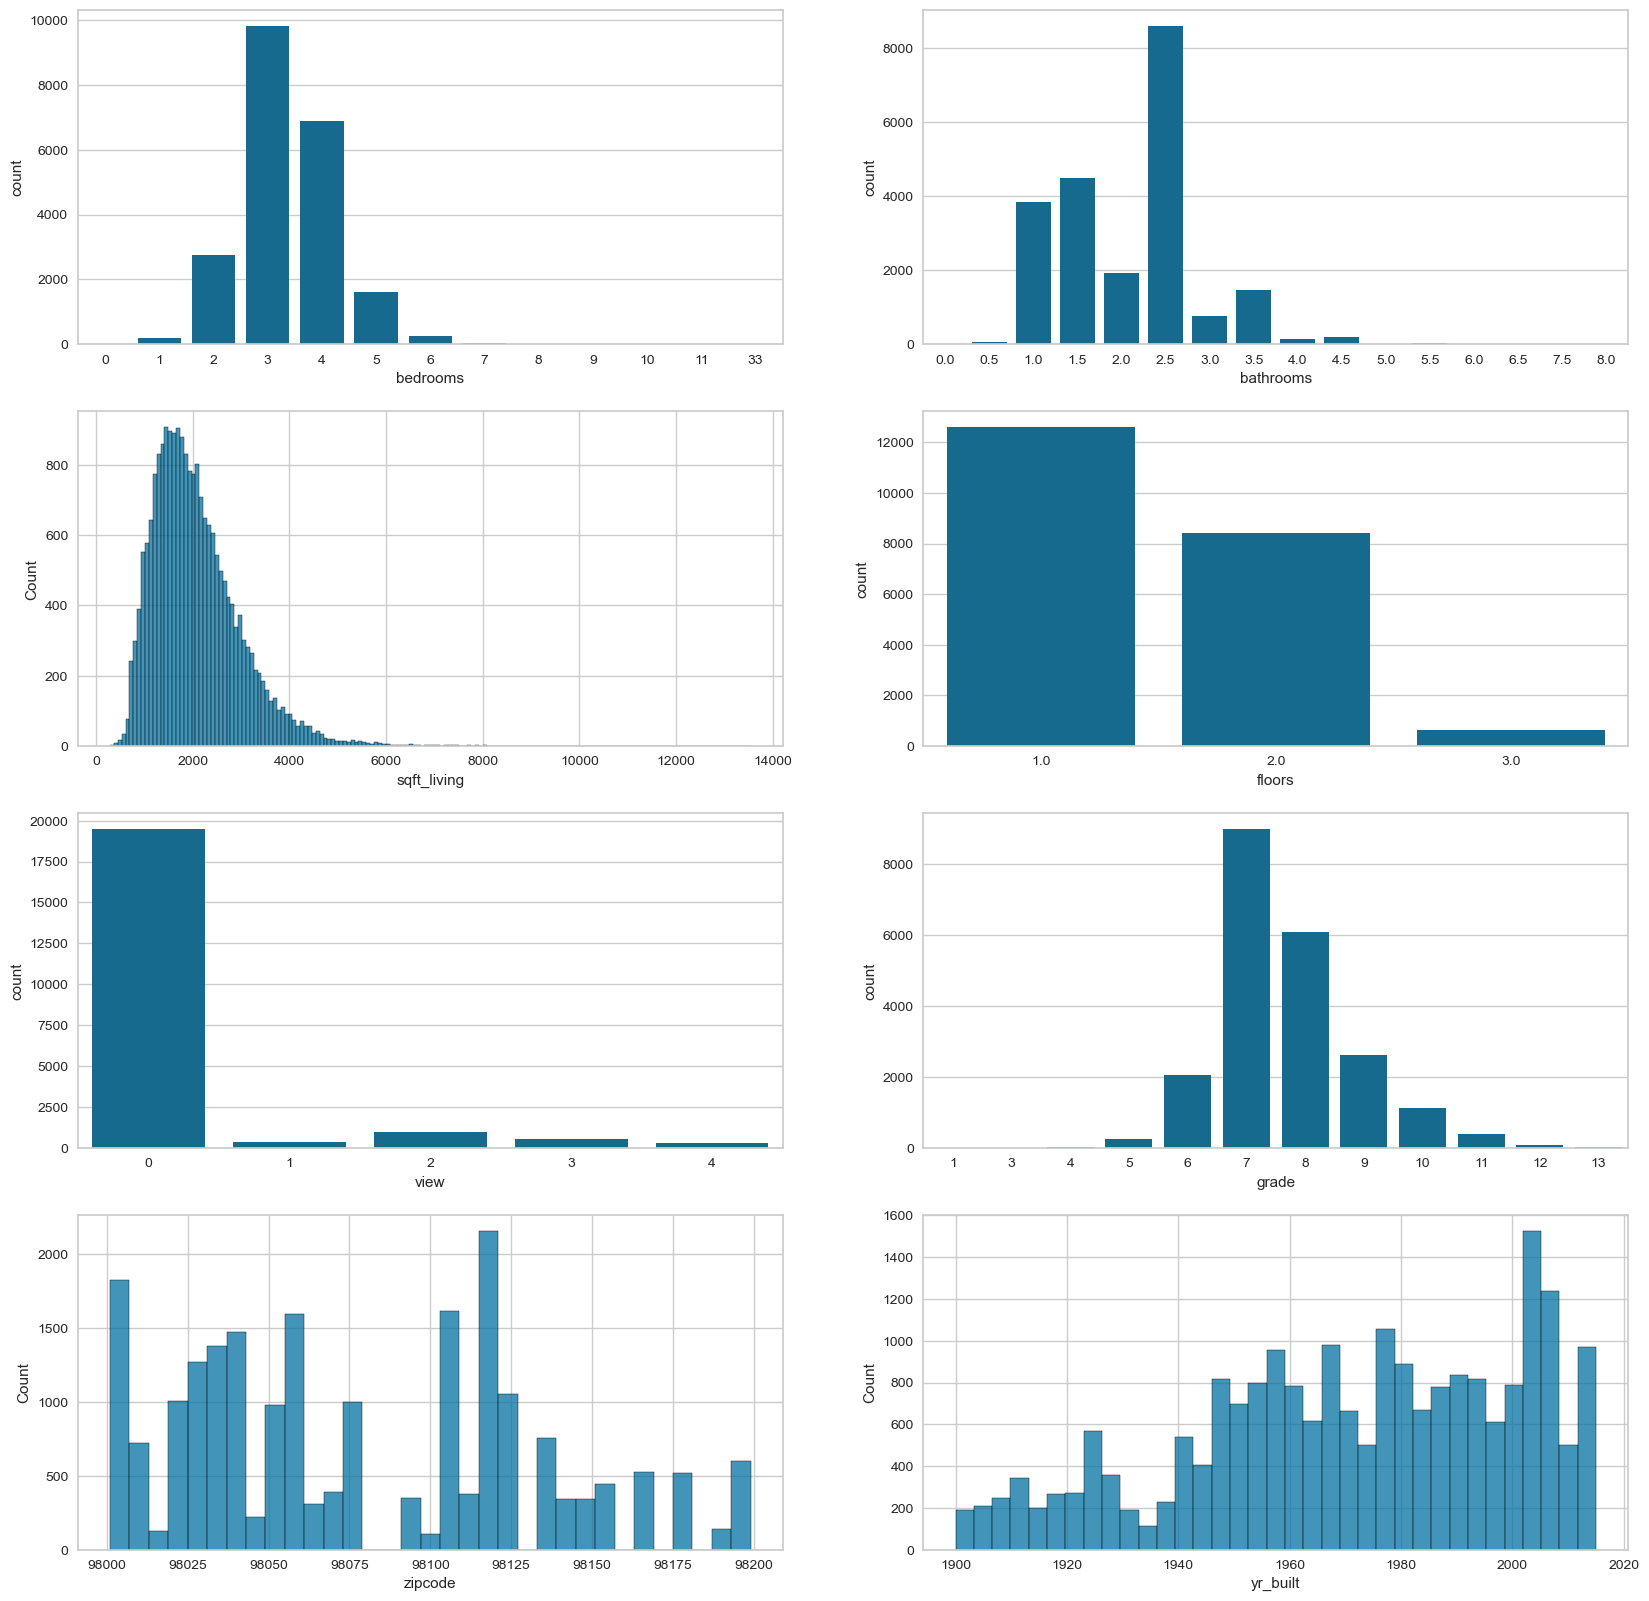

In [12]:
#### Visualisation de quelques variables explicatives
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
sns.countplot(x = data['bedrooms'],  ax= axes[0, 0])
sns.countplot(x = data['bathrooms'],  ax= axes[0, 1])
sns.histplot(x = data['sqft_living'],  ax= axes[1, 0])
sns.countplot(x = data['floors'],  ax= axes[1, 1])
sns.countplot(x = data['view'],  ax= axes[2, 0])
sns.countplot(x = data['grade'],  ax= axes[2, 1])
sns.histplot(x = data['zipcode'],  ax= axes[3, 0])
sns.histplot(x = data['yr_built'],  ax= axes[3, 1])

Interprétations:
- Chambres (bedrooms) : La majorité des maisons ont entre 2 et 4 chambres. Il y a quelques valeurs extrêmes, comme une maison avec 33 chambres.
- Salles de bains (bathrooms) : La plupart des maisons ont entre 1 et 2,5 salles de bains.
- Surface habitable (sqft_living) : Distribution asymétrique à droite, la plupart des maisons ont entre 1 000 et 3 000 pieds carrés.
- Nombre d'étages (floors) : Principalement des maisons à 1 ou 2 étages, très peu avec plus de 3 étages.
- Vue (view) : La majorité des maisons n'ont pas de vue notable (valeur 0).
- Qualité (grade) : La plupart des maisons sont notées entre 6 et 8.
- Code postal (zipcode) : Diversité des propriétés réparties sur plusieurs codes postaux, certains plus fréquents que d'autres.
- Année de construction (yr_built) : Hausse progressive de la construction de maisons au fil des décennies, avec un pic autour des années 2000.

### 2.5 Clustering sur les donnees de localisations

- ####  Détermination du nombre de cluster optimal. (Clustering hierarchique)

In [13]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(data.drop(columns=["id", "date"]))

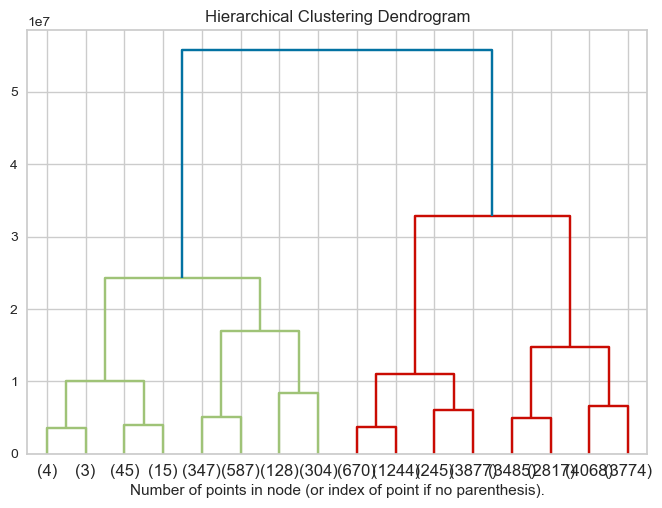

In [14]:
# Dendogramme

def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)
    
    
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()
    
    

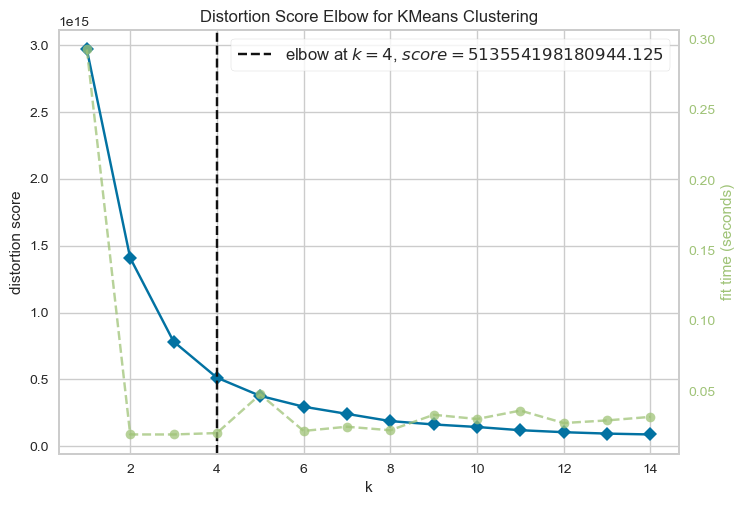

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [15]:
# Methode Elbow

kmeans = KMeans(n_init="auto", random_state=123)
visualizer = KElbowVisualizer(kmeans, k=(1,15))
visualizer.fit(data.drop(columns=["id", "date"]))        
visualizer.show()   

Synthèse:
- Le dendrogramme montre une structure hiérarchique dans les données, laissant entrevoir une coupure possible en 2 à 4 groupes.
- Le graphe Elbow suggère que 4 clusters est optimal.
- Ces deux approches se complètent et valident l’idée qu’il existe 4 grands groupes naturels dans les données analysées.

- ####  Clustering avec k = 4 clusters 

In [16]:
# Clustering
k = 4
coords = data[['lat', 'long']].values
kmeans = KMeans(n_clusters=k, random_state=42)
data['cluster'] = kmeans.fit_predict(coords)

In [17]:
data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,cluster
0,7129300520,2014-10-13,221900.0,3,1.0,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,3
1,6414100192,2014-12-09,538000.0,3,2.5,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,1
2,5631500400,2015-02-25,180000.0,2,1.0,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,1
3,2487200875,2014-12-09,604000.0,4,3.0,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,1
4,1954400510,2015-02-18,510000.0,3,2.0,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2
5,7237550310,2014-05-12,1225000.0,4,4.5,5420,101930,1.0,0,0,...,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930,2
6,1321400060,2014-06-27,257500.0,3,2.5,1715,6819,2.0,0,0,...,1715,0,1995,0,98003,47.3097,-122.327,2238,6819,3
7,2008000270,2015-01-15,291850.0,3,1.5,1060,9711,1.0,0,0,...,1060,0,1963,0,98198,47.4095,-122.315,1650,9711,3
8,2414600126,2015-04-15,229500.0,3,1.0,1780,7470,1.0,0,0,...,1050,730,1960,0,98146,47.5123,-122.337,1780,8113,3
9,3793500160,2015-03-12,323000.0,3,2.5,1890,6560,2.0,0,0,...,1890,0,2003,0,98038,47.3684,-122.031,2390,7570,0


- ####  Analyse en composante principale

In [18]:
# Normalisation des donnees
x = data.drop(columns=['id', 'date', 'long', 'lat', 'cluster']).values
x = StandardScaler().fit_transform(x) # normalizing the feature

In [19]:
pca_house = PCA(n_components=2)
principalComponents_house = pca_house.fit_transform(x)


<Axes: >

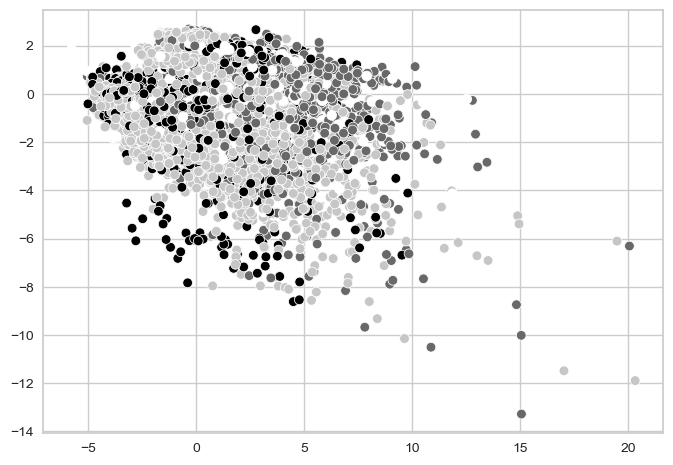

In [20]:
sns.scatterplot(x= principalComponents_house[:, 0], y = principalComponents_house[:, 1], c = data['cluster'])

Le clustering sur les données de localisation donne peu d'information sur les groupes des données.

### 2.6 Analyse et visualisation de la variable a expliquer

<Axes: xlabel='sqft_living', ylabel='price'>

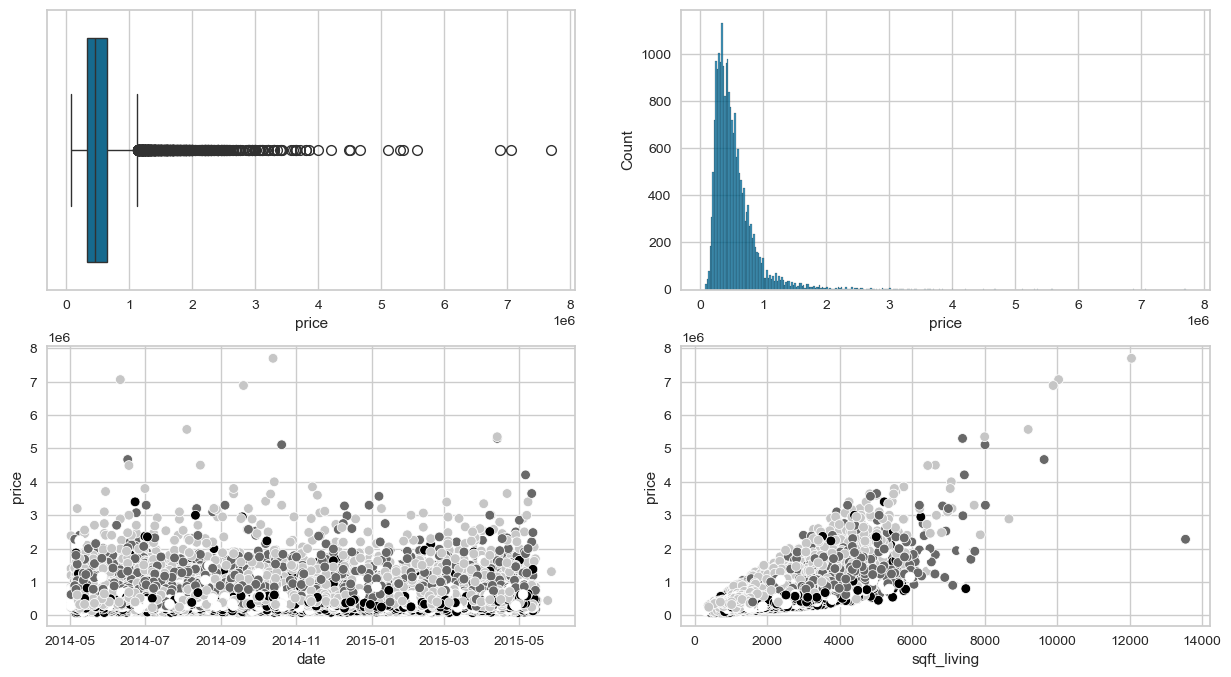

In [21]:
#Visualisation
fig, axes = plt.subplots(2, 2, figsize = (15, 8))
sns.boxplot(data['price'], ax=axes[0, 0], orient='h')
sns.histplot(data['price'], ax=axes[0, 1])
sns.scatterplot(x= data['date'] , y = data['price'], c = data['cluster'], ax=axes[1, 0])
sns.scatterplot(x = data['sqft_living'], y =data['price'],c = data['cluster'],  ax=axes[1, 1])

In [22]:
# Analyse exploratoire
data['price'].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

Analyse: 
- Nous retrouvons des prix des maisons extrement hausse par rapport a la moyenne; nous les considererons comme des outliers pour un model plus performant
- Les clusters ne permettent pas une séparation en groupe des prix des maisons

In [23]:
# Supression des valeurs a 3 ecart-types  de la moyennes
data = data[~(data['price'] > (data['price'].mean() + data['price'].std() *3))]

### 2.7 Feature engineering

In [24]:
## Parsing des dates (extraction des jours, mois et annees)
data['day'] = data['date'].dt.day
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year


In [25]:
data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,cluster,day,month,year
0,7129300520,2014-10-13,221900.0,3,1.0,1180,5650,1.0,0,0,...,0,98178,47.5112,-122.257,1340,5650,3,13,10,2014
1,6414100192,2014-12-09,538000.0,3,2.5,2570,7242,2.0,0,0,...,1991,98125,47.7210,-122.319,1690,7639,1,9,12,2014
2,5631500400,2015-02-25,180000.0,2,1.0,770,10000,1.0,0,0,...,0,98028,47.7379,-122.233,2720,8062,1,25,2,2015
3,2487200875,2014-12-09,604000.0,4,3.0,1960,5000,1.0,0,0,...,0,98136,47.5208,-122.393,1360,5000,1,9,12,2014
4,1954400510,2015-02-18,510000.0,3,2.0,1680,8080,1.0,0,0,...,0,98074,47.6168,-122.045,1800,7503,2,18,2,2015
5,7237550310,2014-05-12,1225000.0,4,4.5,5420,101930,1.0,0,0,...,0,98053,47.6561,-122.005,4760,101930,2,12,5,2014
6,1321400060,2014-06-27,257500.0,3,2.5,1715,6819,2.0,0,0,...,0,98003,47.3097,-122.327,2238,6819,3,27,6,2014
7,2008000270,2015-01-15,291850.0,3,1.5,1060,9711,1.0,0,0,...,0,98198,47.4095,-122.315,1650,9711,3,15,1,2015
8,2414600126,2015-04-15,229500.0,3,1.0,1780,7470,1.0,0,0,...,0,98146,47.5123,-122.337,1780,8113,3,15,4,2015
9,3793500160,2015-03-12,323000.0,3,2.5,1890,6560,2.0,0,0,...,0,98038,47.3684,-122.031,2390,7570,0,12,3,2015


## **Etape 3 : Modélisation**

### 3.1 Sélection des variables

- ####  Supression des variables inutiles

In [26]:
data = data.drop(columns=["id", "date", "lat", "long"])

In [27]:
data.head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15,cluster,day,month,year
0,221900.0,3,1.0,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,1340,5650,3,13,10,2014
1,538000.0,3,2.5,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,1690,7639,1,9,12,2014
2,180000.0,2,1.0,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,2720,8062,1,25,2,2015
3,604000.0,4,3.0,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,1360,5000,1,9,12,2014
4,510000.0,3,2.0,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,1800,7503,2,18,2,2015
5,1225000.0,4,4.5,5420,101930,1.0,0,0,3,11,...,1530,2001,0,98053,4760,101930,2,12,5,2014
6,257500.0,3,2.5,1715,6819,2.0,0,0,3,7,...,0,1995,0,98003,2238,6819,3,27,6,2014
7,291850.0,3,1.5,1060,9711,1.0,0,0,3,7,...,0,1963,0,98198,1650,9711,3,15,1,2015
8,229500.0,3,1.0,1780,7470,1.0,0,0,3,7,...,730,1960,0,98146,1780,8113,3,15,4,2015
9,323000.0,3,2.5,1890,6560,2.0,0,0,3,7,...,0,2003,0,98038,2390,7570,0,12,3,2015


- ####  Matrice de corrélation

<Axes: >

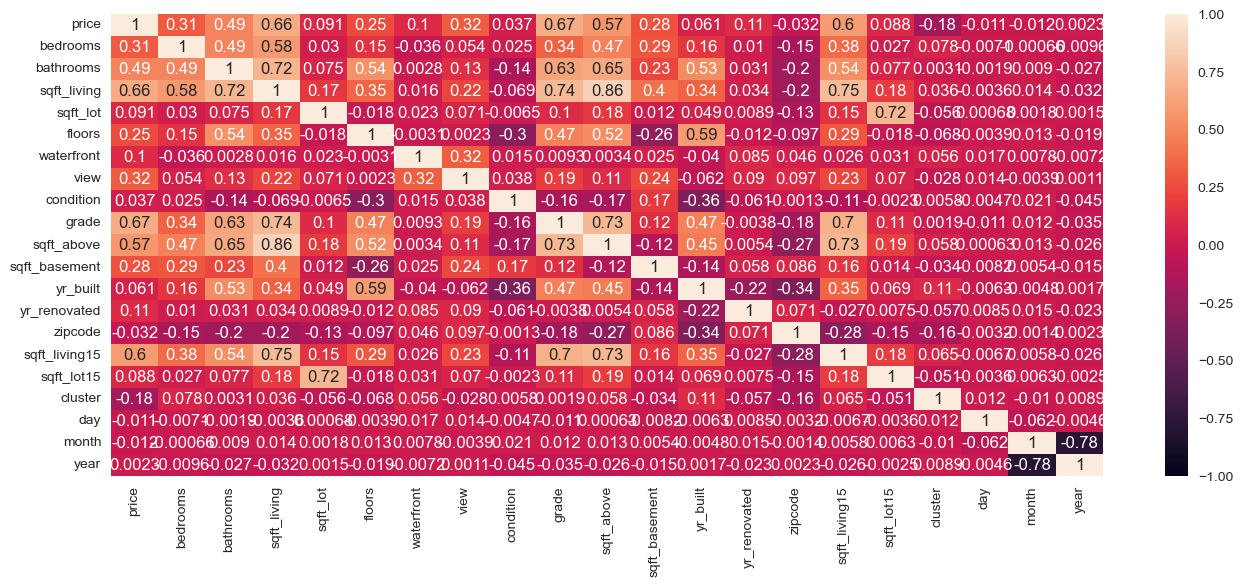

In [28]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.corr(), vmin=-1, vmax=1, annot=True)

Interprétations:
- Les variables bedrooms, bathrooms, sqft_living, view, grade, sqft_above, sqft_basement, sqft_living15 présentent une bonne corrélation par rapport aux prix
- Les variables bathrooms et sqft_living sont fortement corrélées
- Sqft_living et sqft_above présentent une corrélation de 0.86, 0.74 avec grade et de 0.75 avec sqft_living15
- Ainsi nous allons choisir les variables fortement correlees au prix et faiblement correle entre elles pour la creation de notre model

In [29]:
# Supression des colonnes
cols_to_drop = ['sqft_lot', 'floors', 'waterfront' ,'condition', 'sqft_above', 'yr_built', 'yr_renovated', 'zipcode', 'zipcode', 'sqft_lot15',  'cluster', 'day', 'month', 'year']
data = data.drop(columns= cols_to_drop)

In [30]:
# Fixing dataframe raw index apres avoir supprimer les lignes
data = data.reset_index(drop=True)

In [31]:
data.head(10)

,price,bedrooms,bathrooms,sqft_living,view,grade,sqft_basement,sqft_living15
0,221900.0,3,1.0,1180,0,7,0,1340
1,538000.0,3,2.5,2570,0,7,400,1690
2,180000.0,2,1.0,770,0,6,0,2720
3,604000.0,4,3.0,1960,0,7,910,1360
4,510000.0,3,2.0,1680,0,8,0,1800
5,1225000.0,4,4.5,5420,0,11,1530,4760
6,257500.0,3,2.5,1715,0,7,0,2238
7,291850.0,3,1.5,1060,0,7,0,1650
8,229500.0,3,1.0,1780,0,7,730,1780
9,323000.0,3,2.5,1890,0,7,0,2390


### 3.2 Normalisation des données

In [32]:
scaler = StandardScaler()
scaler.fit(data.iloc[:,1:])
data_scaled = scaler.transform(data.iloc[:,1:])
data_prep = pd.DataFrame(data_scaled, columns= data.iloc[:,1:].columns)
data_prep['price'] = data['price']

In [33]:
data_prep.head(10)

,bedrooms,bathrooms,sqft_living,view,grade,sqft_basement,sqft_living15,price
0,-0.383902,-1.385011,-1.017868,-0.29048,-0.543753,-0.660104,-0.946609,221900.0
1,-0.383902,0.565316,0.642559,-0.29048,-0.543753,0.280298,-0.412525,538000.0
2,-1.469280,-1.385011,-1.507634,-0.29048,-1.443587,-0.660104,1.159207,180000.0
3,0.701475,1.215425,-0.086118,-0.29048,-0.543753,1.479311,-0.916090,604000.0
4,-0.383902,-0.084793,-0.420592,-0.29048,0.356081,-0.660104,-0.244670,510000.0
5,0.701475,3.165753,4.047032,-0.29048,3.055584,2.936935,4.272151,1225000.0
6,-0.383902,0.565316,-0.378783,-0.29048,-0.543753,-0.660104,0.423697,257500.0
7,-0.383902,-0.734902,-1.161214,-0.29048,-0.543753,-0.660104,-0.473563,291850.0
8,-0.383902,-1.385011,-0.301137,-0.29048,-0.543753,1.056130,-0.275189,229500.0
9,-0.383902,0.565316,-0.169736,-0.29048,-0.543753,-0.660104,0.655642,323000.0


### 3.3 Division des données en données de test et d'entrainement

In [34]:
## Split test and train 0.8
X = data_prep.iloc[:, :-1]
y = data_prep["price"] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [35]:
# check dimension of every splited dataset
print(data_prep.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(21207, 8)
(16965, 7)
(4242, 7)
(16965,)
(4242,)


### 3.4 Modélisation

Pour la création de notre modèle, nous avons décidé d'effectuer un test comparatif entre 3 algorithmes de prédiction:
- Linear Regression
- Random Forest
- Les réseaux de neuronnes

### *Linear Regression*

In [36]:
lg = LinearRegression()
lg.fit(X_train, y_train)
ylg_pred = lg.predict(X_test)

### *Random Forest*

In [37]:
rfg = RandomForestRegressor(random_state=42)
rfg.fit(X, y)
yrfg_pred = rfg.predict(X_test)

### *Réseaux de neuronnes*

In [38]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dense(64, activation='relu')) 
model.add(tf.keras.layers.Dense(1))  
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

In [39]:
# Entraînement final
model.fit( X_train, y_train, validation_split=0.2, epochs=100, batch_size=16, verbose=1 )

Epoch 1/100
849/849 [==============================] - 2s 1ms/step - loss: 115125403648.0000 - val_loss: 37644632064.0000
Epoch 2/100
849/849 [==============================] - 1s 1ms/step - loss: 31394398208.0000 - val_loss: 30891583488.0000
Epoch 3/100
849/849 [==============================] - 1s 1ms/step - loss: 29492518912.0000 - val_loss: 30474838016.0000
Epoch 4/100
849/849 [==============================] - 1s 1ms/step - loss: 29205651456.0000 - val_loss: 30464051200.0000
Epoch 5/100
849/849 [==============================] - 1s 1ms/step - loss: 29043396608.0000 - val_loss: 30295146496.0000
Epoch 6/100
849/849 [==============================] - 1s 1ms/step - loss: 28909496320.0000 - val_loss: 30605441024.0000
Epoch 7/100
849/849 [==============================] - 1s 1ms/step - loss: 28828786688.0000 - val_loss: 30417823744.0000
Epoch 8/100
849/849 [==============================] - 2s 2ms/step - loss: 28738805760.0000 - val_loss: 30240405504.0000
Epoch 9/100
849/849 [==========

In [40]:
yrn_pred = model.predict(X_test).flatten()

133/133 [==============================] - 0s 1ms/step


### 3.5 Evaluation

In [41]:
# Calcul des métriques

### Linear Regression
mae = mean_absolute_error(y_test, ylg_pred)
rmse = np.sqrt(mean_squared_error(y_test, ylg_pred))
r2 = r2_score(y_test, ylg_pred)

print("----------- Regression Linéaire -------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

### Random Forest
mae = mean_absolute_error(y_test, yrfg_pred)
rmse = np.sqrt(mean_squared_error(y_test, yrfg_pred))
r2 = r2_score(y_test, yrfg_pred)

print("----------- Random Forest -------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

### Réseaux de neurones 
mae = mean_absolute_error(y_test, yrn_pred)
rmse = np.sqrt(mean_squared_error(y_test, yrn_pred))
r2 = r2_score(y_test, yrn_pred)

print("----------- Réseaux de neurones -------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

----------- Regression Linéaire -------------
MAE : 131592.49
RMSE : 178122.52
R² Score : 0.5238
----------- Random Forest -------------
MAE : 50662.60
RMSE : 69291.86
R² Score : 0.9279
----------- Réseaux de neurones -------------
MAE : 127558.17
RMSE : 174456.49
R² Score : 0.5432


- Le modèle de regression lineaire explique environ 52 % de la variance des prix. Cela indique que les relations entre les variables et le prix ne sont probablement pas linéaires ou trop complexes pour être bien modélisées par une régression simple
- Random Forest donne un très bon score : ce modèle explique près de 93 % de la variance
- Le modèle de réseaux de neuronnes est égèrement meilleur que la régression linéaire, mais nettement moins performant que le Random Forest.


### 3.6 Exportation du modèle

In [ ]:
# Exportation du modele
with open('random_forest_model.pkl', 'wb') as fichier_modele:
    pickle.dump(rfg, fichier_modele)

In [43]:
# Exportation du scaler
with open('scaler.pkl', 'wb') as fichier_transformation:
    pickle.dump(scaler, fichier_transformation)

## **Etape 4 : Conclusion**

Après avoir parcouru des étapes allant de le l'importation du jeu de données a l'analyse, le traitement de données et la modélisation. Nous avons pu créer un modèle de prédiction plutot performant de prédiction des prix de maisons dans la ville de King a Seattle. Ce modèle ainsi pourra etre utile en situation réelle et professionnelle par des agences immobilières ou des particuliers.

Pour un mise en démo de celui-ci, nous avons décidé de créer une application streamlit que vous trouverez en cliquant sur le lien suivant: 